https://github.com/4GeeksAcademy/random-forest-project-tutorial/blob/main/solution.es.ipynb

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from scipy.stats import randint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

In [15]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

# **0. CONTEXTO Y CARGA DATOS**

Mismo análisis que en ``04-decission-tree.ipynb``, pero aplicando el algoritmo ``Random Forest``

In [16]:
# Cargamos la base de datos
df=pd.read_csv(("diabetes.csv")).drop(columns="Unnamed: 0")
#Hacemos train test split (mismo que en 04-decission-tree.ipynb)
X_train = df.iloc[:608].drop(columns=["Outcome"])
X_test = df.iloc[608:].drop(columns=["Outcome"])
y_train = df["Outcome"].iloc[:608]
y_test = df["Outcome"].iloc[608:]
#Comprobamos split
print(X_train.mean(), "\n","-"*50,"\n",X_test.mean())

Glucose                    121.77236
BloodPressure               71.94767
SkinThickness               29.22852
BMI                         32.50085
DiabetesPedigreeFunction    -0.94391
Age                         33.48520
Pregna/Age                   2.17284
dtype: float64 
 -------------------------------------------------- 
 Glucose                    122.33635
BloodPressure               74.14304
SkinThickness               29.13904
BMI                         32.25229
DiabetesPedigreeFunction    -0.99658
Age                         32.67974
Pregna/Age                   2.21159
dtype: float64


# 1. Entrenamiento del modelo

In [17]:
#Cargamos el árbol optimizado
modelo=pickle.load(open("DT.sav", "rb"))
print(modelo.get_params)

<bound method BaseEstimator.get_params of DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=22,
                       min_samples_split=54, random_state=42)>


In [35]:
# Definimos hiperparámetros
param_grid = {
    'n_estimators': randint(50,200),
    'max_depth': randint(2,23),
    'min_samples_leaf': randint(1,60),
    'min_samples_split': randint(2,120),
    'criterion': ["gini", "entropy"]} #Numeros aleatorios entre el rango observado

# Configurar GridSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    verbose=4,
    n_jobs=-1,
    random_state=42,
)

# Ejecutamos la búsqueda 
random_search.fit(X_train, y_train)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
random_mod = random_search.best_estimator_ #Guardamos los resultados

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros:
{'criterion': 'gini', 'max_depth': 17, 'min_samples_leaf': 15, 'min_samples_split': 73, 'n_estimators': 89}


# 2. Evaluación del modelo

------------------------------------------------------------
GONFIGURACIÓN INICIAL
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision       F1
Train        0.78783  0.58796      0.89796    0.76048  0.66319
Test         0.81046  0.62745      0.90196    0.76190  0.68817
Diferencia  -0.02263 -0.03949     -0.00400   -0.00143 -0.02499


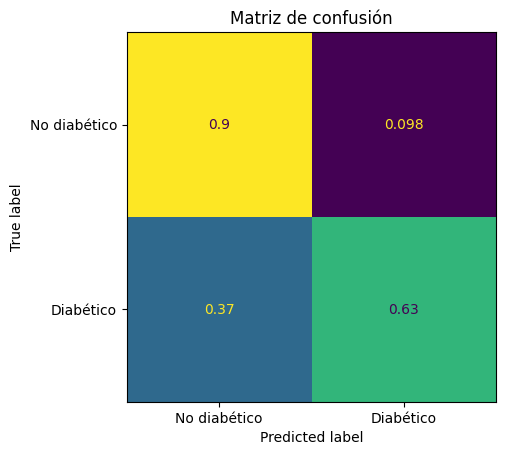

In [32]:
#Predicciones
train_pred = random_mod.predict(X_train)
test_pred = random_mod.predict(X_test)
## Métricas
print("-"*60)
print("GONFIGURACIÓN INICIAL")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))

##Matriz de confusión
cm = confusion_matrix(y_test, test_pred, labels=[0, 1], normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No diabético", "Diabético"])
disp.plot(cmap="viridis", colorbar=False)
plt.title("Matriz de confusión")
plt.show()

# 3. Optimización de hiperparámetros

In [36]:
# Evolución del f1 score por cada nuevo arbol entrenado
scores = []
#Bucle para entrenar los n estimadores pues oob_score_ proporciona la metrica del último árbol 
for n in range(1, random_mod.n_estimators + 1):
    modelo_parcial = RandomForestClassifier(n_estimators=n, oob_score=f1_score, warm_start=True, random_state=42)
    modelo_parcial.fit(X_train, y_train)
    scores.append(modelo_parcial.oob_score_)

scores=pd.Series(scores)

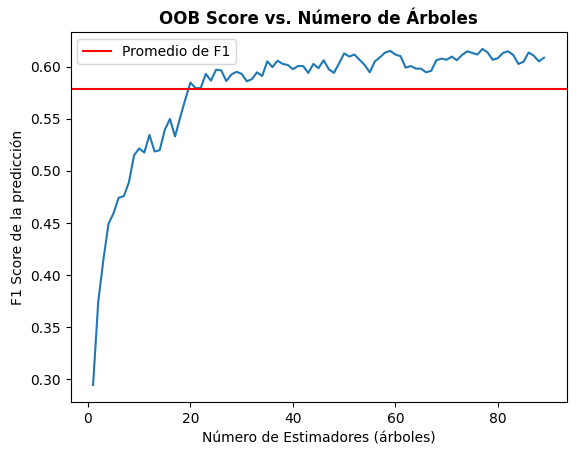

In [52]:
#Visualizamos el proceso
plt.plot(scores.index+1, scores)
plt.title("OOB Score vs. Número de Árboles", fontweight='bold')
plt.xlabel("Número de Estimadores (árboles)")
plt.axhline(y=scores.mean(), color='r', label="Promedio de F1")
plt.ylabel("F1 Score de la predicción")
plt.legend()
plt.show()

In [ ]:
#Numero de arboles entrenados por encima del percentil 95 de f1
scores[scores>scores.quantile(0.95)]

58   0.61500
73   0.61461
76   0.61692
81   0.61461
dtype: float64

Una vez halladas estas concreciones que generan métricas similares en torno a un 61,5% de f1 score, haremos una busqueda intensiva para ver si un modelo con un menor numero de árboles entrenados es capaz de obtener un resultado más preciso.

In [ ]:
# Definimos hiperparámetro más importante
param_grid = {
   "n_estimators": [58,73,76,81]}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(criterion='gini', 
                                     max_depth=17,
                                     min_samples_leaf=15,
                                     min_samples_split=73,
                                     n_estimators=89),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation 
    scoring='recall',  # Minimizamos VP
    n_jobs=-1,
    verbose=2  # Mostrar progreso
)

# Ejecutamos la búsqueda 
grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros:")
print(grid_search.best_params_)
grid_mod = grid_search.best_estimator_ #Guardamos los resultados

##Predicciones
train_pred_opt = grid_mod.predict(X_train)
test_pred_opt = grid_mod.predict(X_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores hiperparámetros:
{'n_estimators': 58}


In [54]:
#Comparación de métricas
## Métricas
print("-"*60)
print("MODELO SIN OPTIMIZAR")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))
## Métricas
print("-"*60)
print("MODELO OPTIMIZADO")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred_opt, test_pred_opt))

------------------------------------------------------------
MODELO SIN OPTIMIZAR
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision       F1
Train        0.78783  0.58796      0.89796    0.76048  0.66319
Test         0.81046  0.62745      0.90196    0.76190  0.68817
Diferencia  -0.02263 -0.03949     -0.00400   -0.00143 -0.02499
------------------------------------------------------------
MODELO OPTIMIZADO
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.80428 0.60648      0.91327    0.79394 0.68766
Test         0.79085 0.58824      0.89216    0.73171 0.65217
Diferencia   0.01343 0.01825      0.02111    0.06223 0.03549


[]

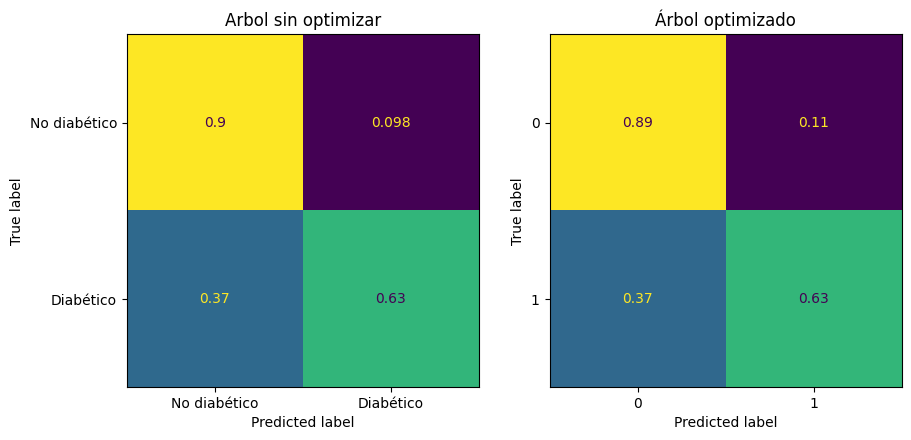

In [12]:
#Matriz de confusión
## Sin Optimizar
cm1 = confusion_matrix(y_test, test_pred, normalize='true')
## Optimizado
cm2 = confusion_matrix(y_test, test_pred_opt, normalize='true')

# Representación
fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["No diabético", "Diabético"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Arbol sin optimizar")
ConfusionMatrixDisplay(confusion_matrix=cm2).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Árbol optimizado")
plt.plot()

Con estos resultados, podemos observar como el numero de árboles parece estar ya optimizado de base dado que si reducimosel modelo de 89 a 58 árboles, incrementamos el procentaje de diabéticos incorrectamente clasificados en 0.2 puntos porcentuales.

In [55]:
#Exportamos el modelo con joblib (más rápido que pickle)
joblib.dump(random_mod, "RF.joblib")

['RF.joblib']